In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.readwrite import json_graph
import json

In [ ]:

# ------------------------------------------------------------------------------
# 1. Load CSV into DataFrame
# ------------------------------------------------------------------------------

def load_meter_data(csv_path):
    """Load telemetry meter data from a CSV file."""
    return pd.read_csv(csv_path)

# ------------------------------------------------------------------------------
# 2. Build Directed Graph from Site Data
# ------------------------------------------------------------------------------

def build_graph_for_site(df, site_id):
    """
    Build a directed graph for a specific site.
    Each node is a meter, and edges point from parent to attached (downstream).
    """
    site_df = df[df['site'] == site_id]
    G = nx.DiGraph()

    for _, row in site_df.iterrows():
        meter = row['meter_id']
        G.add_node(meter, **row.to_dict())
        if pd.notna(row['attached_to']):
            G.add_edge(row['attached_to'], meter)

    return G

# ------------------------------------------------------------------------------
# 3. Visualize the Graph
# ------------------------------------------------------------------------------

def visualize_graph(G, title="Meter Graph"):
    """
    Visualize the graph using matplotlib.
    Primary meters are colored differently.
    """
    node_colors = [
        'skyblue' if G.nodes[n].get('type') == 'primary' else 'lightgreen'
        for n in G.nodes
    ]
    pos = nx.spring_layout(G, seed=42)  # consistent layout
    plt.figure(figsize=(10, 6))
    nx.draw(
        G, pos, with_labels=True, node_color=node_colors,
        node_size=1200, edge_color='gray'
    )
    plt.title(title)
    plt.show()

# ------------------------------------------------------------------------------
# 4. Subgraph Queries
# ------------------------------------------------------------------------------

def get_downstream_subgraph(G, root_meter_id):
    """
    Return a subgraph containing all meters downstream from a given meter.
    """
    descendants = nx.descendants(G, root_meter_id)
    sub_nodes = [root_meter_id] + list(descendants)
    return G.subgraph(sub_nodes).copy()

def get_upstream_path(G, meter_id):
    """
    Return a subgraph containing the upstream path from a given meter to the root.
    Assumes a single-parent hierarchy (tree-like).
    """
    path = []
    current = meter_id
    while True:
        preds = list(G.predecessors(current))
        if not preds:
            break
        parent = preds[0]
        path.append(parent)
        current = parent
    return G.subgraph([meter_id] + path).copy()

def filter_by_metadata(G, key, value):
    """
    Return a subgraph of nodes matching a specific metadata value.
    """
    nodes = [n for n, d in G.nodes(data=True) if d.get(key) == value]
    return G.subgraph(nodes).copy()

# ------------------------------------------------------------------------------
# 5. Export Graph to JSON
# ------------------------------------------------------------------------------

def export_graph_to_json(G, filename):
    """
    Export the graph to a JSON file using node-link format.
    """
    data = json_graph.node_link_data(G)
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2)


In [ ]:

# ------------------------------------------------------------------------------
# 6. Example Workflow
# ------------------------------------------------------------------------------

# Load the data
df = load_meter_data("telemetry_meters.csv")
df.head()

In [ ]:
# Build the graph for Site 1
G_site1 = build_graph_for_site(df, "Site 1")
# Visualize the full graph
visualize_graph(G_site1, "Site 1 - Full Meter Graph")

In [ ]:
# Visualize downstream from Meter 2
G_down = get_downstream_subgraph(G_site1, "Meter 2")
visualize_graph(G_down, "Downstream of Meter 2")

In [14]:
# Visualize upstream path to Meter 5
G_up = get_upstream_path(G_site1, "Meter 5")
G_up
# visualize_graph(G_up, "Upstream Path to Meter 5")

In [ ]:
# Visualize meters by location
G_loc = filter_by_metadata(G_site1, "location", "Level 1")
visualize_graph(G_loc, "Meters in Level 1")

In [ ]:
# Export a subgraph to JSON
export_graph_to_json(G_down, "exports/downstream_meter2.json")

## Other Features

### Metadata

In [21]:
def filter_by_metadata(G, key, value):
    """
    Filter nodes by a single metadata key-value pair.
    """
    return G.subgraph([n for n, d in G.nodes(data=True) if d.get(key) == value]).copy()

def filter_by_metadata_multiple(G, conditions):
    """
    Filter nodes by multiple metadata conditions.
    Example: conditions = {"zone": "Zone A", "status": "active"}
    """
    def match_all(data):
        return all(data.get(k) == v for k, v in conditions.items())

    return G.subgraph([n for n, d in G.nodes(data=True) if match_all(d)]).copy()

import pandas as pd

def graph_metadata_to_dataframe(G):
    """
    Convert node attributes in a NetworkX graph to a pandas DataFrame.

    Each row corresponds to a meter, and all metadata attributes
    (including site, location, type, etc.) are included as columns.

    Parameters:
        G (networkx.Graph): A graph with nodes having attribute dictionaries.

    Returns:
        pd.DataFrame: DataFrame of node attributes.
    """
    records = []
    for node, data in G.nodes(data=True):
        record = {"meter_id": node}
        record.update(data)
        records.append(record)
    return pd.DataFrame(records)



In [16]:
# Load updated CSV
df = pd.read_csv("telemetry_meters.csv")

# Build graph for a specific site
G_site1 = build_graph_for_site(df, "Site 1")

In [25]:
# Example: Get metadata of all nodes in Site 1 graph
df_metadata = graph_metadata_to_dataframe(G_site1)
print(df_metadata)

  meter_id    site attached_to    location flow_direction     type    zone  \
0  Meter 1  Site 1         NaN  Main Inlet         inflow  primary  Zone A   
1  Meter 2  Site 1     Meter 1  Building A         inflow      sub  Zone A   
2  Meter 3  Site 1     Meter 1  Building B         inflow      sub  Zone B   
3  Meter 4  Site 1     Meter 2     Level 1         inflow      sub  Zone A   
4  Meter 5  Site 1     Meter 2     Level 2         inflow      sub  Zone A   
5  Meter 6  Site 1     Meter 3    Workshop         inflow      sub  Zone B   

  installation_date       status maintenance_priority  
0        2021-01-15       active                 high  
1        2021-01-20       active               medium  
2        2021-02-01       active               medium  
3        2021-03-01  maintenance                 high  
4        2021-03-10       active                  low  
5        2021-04-05       active                  low  


In [20]:
# Filter: All meters in Zone A
G_zone_a = filter_by_metadata(G_site1, "zone", "Zone A")
# visualize_graph(G_zone_a, "Zone A Meters")

In [19]:
# Filter: All active meters with high maintenance priority
conditions = {"status": "active", "maintenance_priority": "high"}
G_high_priority = filter_by_metadata_multiple(G_site1, conditions)
# visualize_graph(G_high_priority, "Active High Priority Meters")

In [ ]:
# Example: Get metadata of a filtered subgraph
G_filtered = filter_by_metadata(G_site1, "status", "maintenance")
df_filtered = graph_metadata_to_dataframe(G_filtered)
print(df_filtered)

  meter_id    site attached_to location flow_direction type    zone  \
0  Meter 4  Site 1     Meter 2  Level 1         inflow  sub  Zone A   

  installation_date       status maintenance_priority  
0        2021-03-01  maintenance                 high  


### Graph Properties

In [26]:
def hierarchy_levels(G):
    """
    Assigns a hierarchy level (depth) to each node using topological sort.

    Returns:
        dict: {meter_id: level}
    """
    levels = {}
    for node in nx.topological_sort(G):
        preds = list(G.predecessors(node))
        if not preds:
            levels[node] = 0
        else:
            levels[node] = max(levels[p] for p in preds) + 1
    return levels



In [27]:
# Hierarchy levels
levels = hierarchy_levels(G_site1)
for meter, level in levels.items():
    print(f"{meter}: Level {level}")


Meter 1: Level 0
Meter 2: Level 1
Meter 3: Level 1
Meter 4: Level 2
Meter 5: Level 2
Meter 6: Level 2


### Flows

In [43]:
# ------------------------------
# Sample Telemetry Data Creation
# ------------------------------

def generate_sample_telemetry():
    data = []
    meters = {
        "Site 1": ["Meter 1", "Meter 2", "Meter 3", "Meter 4", "Meter 5", "Meter 6"],
        "Site 2": ["Meter 1", "Meter 2", "Meter 3"],
        "Site 3": ["Meter 1", "Meter 2", "Meter 3", "Meter 4"]
    }
    timestamps = pd.date_range("2024-01-01 00:00", periods=3, freq="D")

    for ts in timestamps:
        for site, meter_list in meters.items():
            for meter in meter_list:
                reading = 100 + hash((site, meter, ts)) % 500  # pseudo-random
                data.append({"site": site, "meter_id": meter, "timestamp": ts, "reading": reading})
    return pd.DataFrame(data)

# ---------------------
# Structure Load + Graph
# ---------------------

def load_meter_structure():
    csv = """site,meter_id,attached_to,location,flow_direction,type
Site 1,Meter 1,,Main Inlet,inflow,primary
Site 1,Meter 2,Meter 1,Building A,inflow,sub
Site 1,Meter 3,Meter 1,Building B,inflow,sub
Site 1,Meter 4,Meter 2,Level 1,inflow,sub
Site 1,Meter 5,Meter 2,Level 2,inflow,sub
Site 1,Meter 6,Meter 3,Workshop,inflow,sub
Site 2,Meter 1,,Main Inlet,inflow,primary
Site 2,Meter 2,Meter 1,Warehouse,inflow,sub
Site 2,Meter 3,Meter 2,Cold Storage,inflow,sub
Site 3,Meter 1,,Main Inlet,inflow,primary
Site 3,Meter 2,Meter 1,Admin Block,inflow,sub
Site 3,Meter 3,Meter 1,Mechanical Room,inflow,sub
Site 3,Meter 4,Meter 2,2nd Floor,inflow,sub"""
    from io import StringIO
    return pd.read_csv(StringIO(csv))

def build_graph_for_site(df, site):
    df_site = df[df["site"] == site]
    G = nx.DiGraph()
    for _, row in df_site.iterrows():
        meter_id = row["meter_id"]
        G.add_node(meter_id, **row.drop(["site", "meter_id"]).to_dict())
        if pd.notna(row["attached_to"]):
            G.add_edge(row["attached_to"], meter_id)
    return G

# ---------------------
# Telemetry Integration
# ---------------------

def join_structure_with_telemetry(structure_df, telemetry_df):
    return pd.merge(telemetry_df, structure_df, on=["site", "meter_id"], how="left")

def sum_downstream_readings(G, telemetry_df, timestamp):
    telemetry_snapshot = telemetry_df[telemetry_df["timestamp"] == timestamp].set_index("meter_id")["reading"].to_dict()
    summed_readings = {}

    def get_total(meter):
        if meter in summed_readings:
            return summed_readings[meter]
        total = telemetry_snapshot.get(meter, 0)
        for child in G.successors(meter):
            total += get_total(child)
        summed_readings[meter] = total
        return total

    for meter in G.nodes:
        get_total(meter)

    return summed_readings

def flag_consumption_anomalies(df_joined, threshold=0.2):
    anomalies = []
    for (site, ts), group in df_joined.groupby(["site", "timestamp"]):
        meters = group.set_index("meter_id")
        parent_map = meters["attached_to"].dropna()
        for child, parent in parent_map.items():
            if parent not in meters.index:
                continue
            parent_val = meters.at[parent, "reading"]
            child_val = meters.at[child, "reading"]
            if parent_val == 0: continue
            deviation = abs(parent_val - child_val) / parent_val
            if deviation > threshold:
                anomalies.append({
                    "site": site,
                    "timestamp": ts,
                    "parent": parent,
                    "child": child,
                    "parent_reading": parent_val,
                    "child_reading": child_val,
                    "deviation": deviation
                })
    return pd.DataFrame(anomalies)

def visualize_graph_with_readings(G, readings_dict, title="Meter Flow"):
    pos = nx.spring_layout(G, seed=42)
    labels = {node: f"{node}\n{readings_dict.get(node, 'N/A')}" for node in G.nodes}
    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, with_labels=True, labels=labels, node_color="lightblue", edge_color="gray", node_size=1200)
    plt.title(title)
    plt.show()

def sum_downstream_readings_over_time(G, telemetry_df):
    """
    Computes total downstream readings for all meters across all timestamps.
    
    Returns:
        pd.DataFrame with columns: ['timestamp', 'meter_id', 'total_downstream_reading']
    """
    results = []

    # Preload meter list from graph (to ensure correct hierarchy)
    meters = list(nx.topological_sort(G))

    for timestamp, group in telemetry_df.groupby("timestamp"):
        snapshot = group.set_index("meter_id")["reading"].to_dict()
        totals = {}

        def get_total(meter):
            if meter in totals:
                return totals[meter]
            total = snapshot.get(meter, 0)
            for child in G.successors(meter):
                total += get_total(child)
            totals[meter] = total
            return total

        for meter in meters:
            total = get_total(meter)
            results.append({
                "timestamp": timestamp,
                "meter_id": meter,
                "total_downstream_reading": total
            })

    return pd.DataFrame(results)


def plot_downstream_readings_timeseries(df_summed, meters=None, title="Downstream Readings Over Time"):
    """
    Plot total downstream readings over time for selected meters.

    Args:
        df_summed (pd.DataFrame): Output from sum_downstream_readings_over_time with columns ['timestamp', 'meter_id', 'total_downstream_reading'].
        meters (list[str], optional): List of meter IDs to plot. If None, plot all.
        title (str): Plot title.
    """
    df_plot = df_summed.copy()
    if meters is not None:
        df_plot = df_plot[df_plot["meter_id"].isin(meters)]
    
    # Pivot to wide format: rows timestamps, columns meters
    df_pivot = df_plot.pivot(index="timestamp", columns="meter_id", values="total_downstream_reading")

    plt.figure(figsize=(12, 6))
    for meter in df_pivot.columns:
        plt.plot(df_pivot.index, df_pivot[meter], label=meter)
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Total Downstream Reading")
    plt.legend(title="Meter ID")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def check_children_sum_to_parent(G, telemetry_df):
    anomalies = []

    for timestamp, group in telemetry_df.groupby("timestamp"):
        snapshot = group.set_index("meter_id")["reading"].to_dict()
        for parent in G.nodes:
            children = list(G.successors(parent))
            if not children:
                continue
            parent_reading = snapshot.get(parent, None)
            children_sum = sum(snapshot.get(child, 0) for child in children)
            if parent_reading is None:
                continue
            # Calculate relative difference
            if parent_reading == 0 and children_sum != 0:
                deviation = float("inf")
            else:
                deviation = abs(parent_reading - children_sum) / (parent_reading if parent_reading != 0 else 1)
            
            if deviation > 0.1:  # e.g., 10% tolerance
                anomalies.append({
                    "timestamp": timestamp,
                    "parent": parent,
                    "parent_reading": parent_reading,
                    "children_sum": children_sum,
                    "deviation": deviation
                })
    return pd.DataFrame(anomalies)



In [36]:
# Load data
structure_df = load_meter_structure()
telemetry_df = generate_sample_telemetry()

# Join structure + telemetry
df_joined = join_structure_with_telemetry(structure_df, telemetry_df)

# Analyze one site
site = "Site 1"
timestamp = "2024-01-01 00:00:00"
G = build_graph_for_site(structure_df, site)
site_telemetry = telemetry_df[telemetry_df["site"] == site]


In [45]:
test=check_children_sum_to_parent(G, telemetry_df)
test.head(100)

,timestamp,parent,parent_reading,children_sum,deviation
0,2024-01-01,Meter 1,140,820,4.857143
1,2024-01-01,Meter 2,464,348,0.250000
2,2024-01-01,Meter 3,356,408,0.146067
3,2024-01-02,Meter 1,252,625,1.480159
4,2024-01-02,Meter 2,448,572,0.276786
5,2024-01-02,Meter 3,177,520,1.937853
6,2024-01-03,Meter 1,423,549,0.297872
7,2024-01-03,Meter 2,410,589,0.436585
8,2024-01-03,Meter 3,139,366,1.633094


In [37]:
# Run downstream summarisation across time
df_summed = sum_downstream_readings_over_time(G, site_telemetry)

print(df_summed.head())
# # Summarise telemetry
# reading_totals = sum_downstream_readings(G, telemetry_df[telemetry_df["site"] == site], pd.to_datetime(timestamp))
# print("\n[Downstream Readings at", timestamp, "]")
# for k, v in reading_totals.items():
#     print(f"{k}: {v}")

   timestamp meter_id  total_downstream_reading
0 2024-01-01  Meter 1                      1670
1 2024-01-01  Meter 2                       832
2 2024-01-01  Meter 3                       694
3 2024-01-01  Meter 4                       172
4 2024-01-01  Meter 5                       192


In [38]:
# # Flag anomalies
# anomalies = flag_consumption_anomalies(df_joined)
# print("\n[Anomalies]")
# print(anomalies)


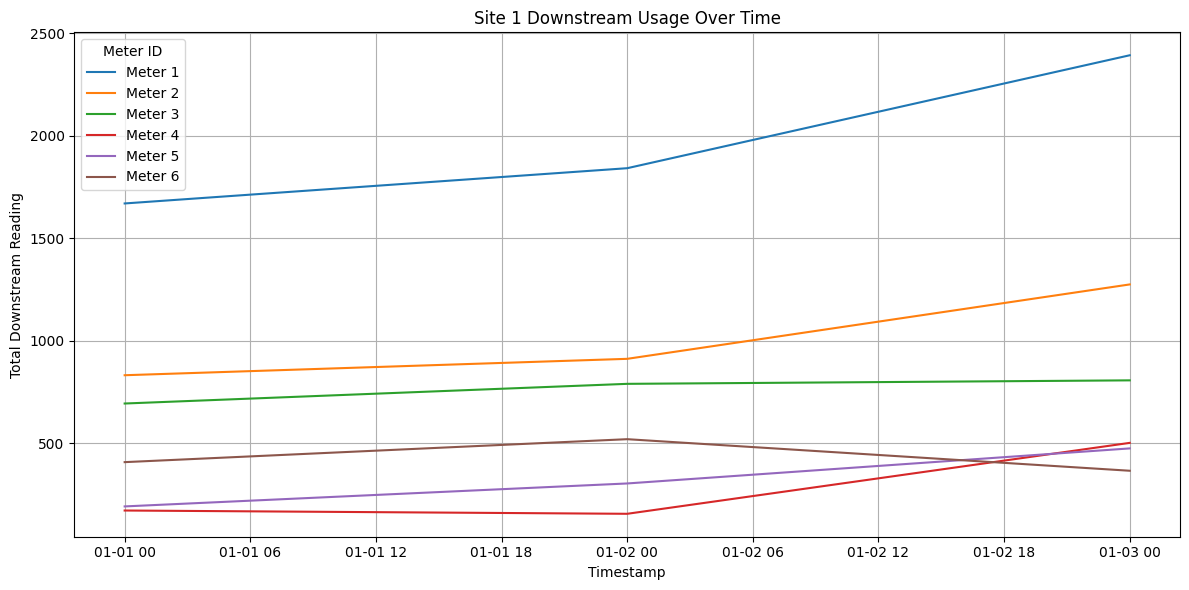

In [ ]:
# Assuming df_summed from previous example and G graph exists
all_meters = list(G.nodes)
plot_downstream_readings_timeseries(df_summed, meters=all_meters, title=f"{site} Downstream Usage Over Time")


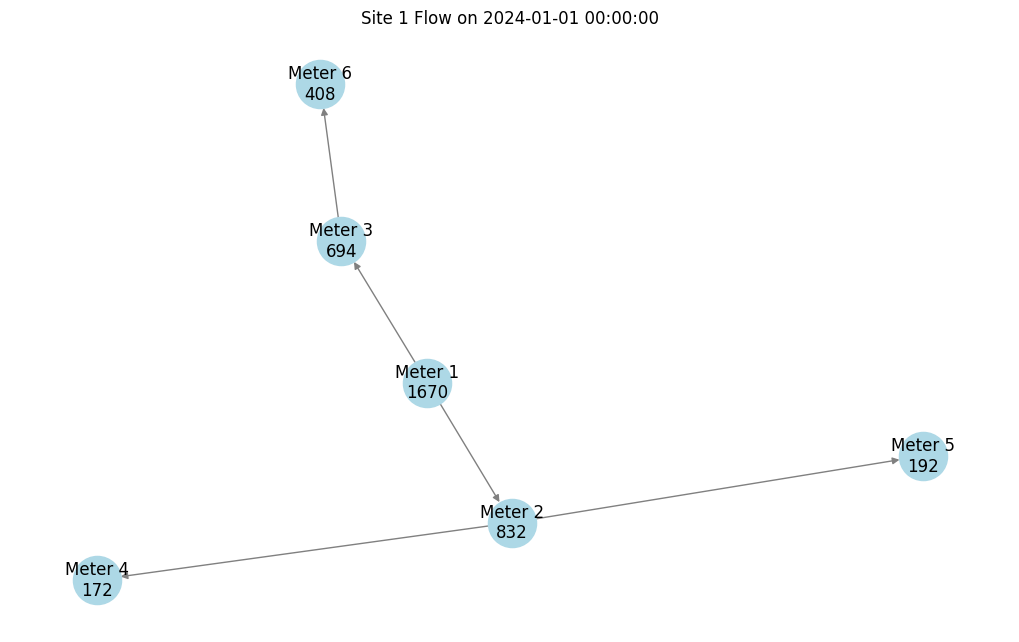

In [46]:

# Visualize
visualize_graph_with_readings(G, reading_totals, title=f"{site} Flow on {timestamp}")
